# Phase I — EDA + Data Quality + Preprocessing Bridge

This notebook covers **Phase I** of the project for **Project 1: Classical ML with Tabular Medical Data**.

## What is contained in this notebook
- **Methods & Data:** dataset source/size, target definition, missingness handling, preprocessing plan, and split strategy.
- **Results & Evaluation:** EDA findings + 2–4 clear figures with captions, and basic statistical evidence for feature/label relationships.
- **Reproducibility:** deterministic splits and saved artifacts (preprocessor + feature list) to ensure Phase II modeling is repeatable.

**Inputs**
- ARFF dataset: `CDK_dataset.arff` (path is configurable via environment variable).

**Outputs (created automatically)**
- Cleaned dataframe export (CSV) and preprocessing artifacts for Phase II modeling.

> Note: Phase II (training 5 models + evaluation) will be in a separate notebook.


## 1) Data Loading & Basic Cleaning

**Goal of this section**
- Load the ARFF file into a DataFrame
- Normalize obvious formatting artifacts (quotes, stray tabs like `\t`, and missing-value marker `?`)
- Ensure the target label column (`classification`) is clean and consistent


In [27]:
# Load the ARFF file into a pandas DataFrame

import numpy as np
import pandas as pd
import arff

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")

PALETTE = {"ckd": "#C44E52", "notckd": "#4C72B0"}

import os

# Use env var if provided; otherwise default to local relative path or this repo path
path = os.environ.get("CKD_ARFF_PATH", "CDK_dataset.arff")
if not os.path.exists(path):
    # fallback for this workspace
    path = "/mnt/data/CDK_dataset.arff"
print("Using ARFF:", path)
with open(path, 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'])
df.columns = [attr[0] for attr in dataset['attributes']]

df.head()

Using ARFF: CDK_dataset.arff


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,None,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,None,normal,notpresent,notpresent,...,38,6000,None,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,None,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [28]:
# Replace "?" with proper missing values - CKD dataset uses "?" instead of NaN.

df = df.replace("?", pd.NA)


In [29]:
# Convert numeric columns properly - Some numeric columns may load as object due to missing values.

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(10))

(400, 26)
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object
rbc     152
rc      130
wc      105
pot      88
sod      87
pcv      70
pc       65
hemo     52
su       49
sg       47
dtype: int64


/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/2088830149.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


## 2) Exploratory Data Analysis

**Goal of this section**
- Summarize class balance (CKD vs NotCKD)
- Visualize clinically meaningful features (e.g., creatinine, hemoglobin, blood urea)
- Quantify missingness patterns


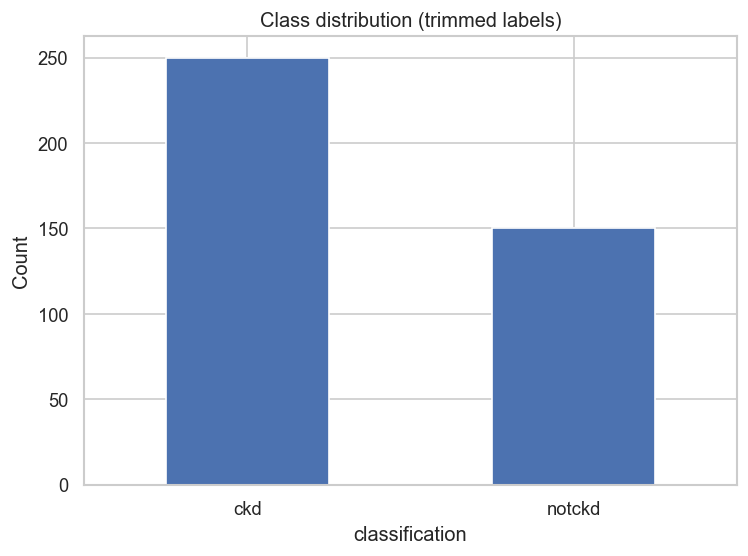

In [30]:
# Class Distribution - This dataset often has values like "ckd" and "notckd" but sometimes with whitespace (trailing spaces).

df["classification"] = df["classification"].astype(str).str.strip()
df["classification"].value_counts().plot(kind="bar")
plt.title("Class distribution (trimmed labels)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/582107333.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


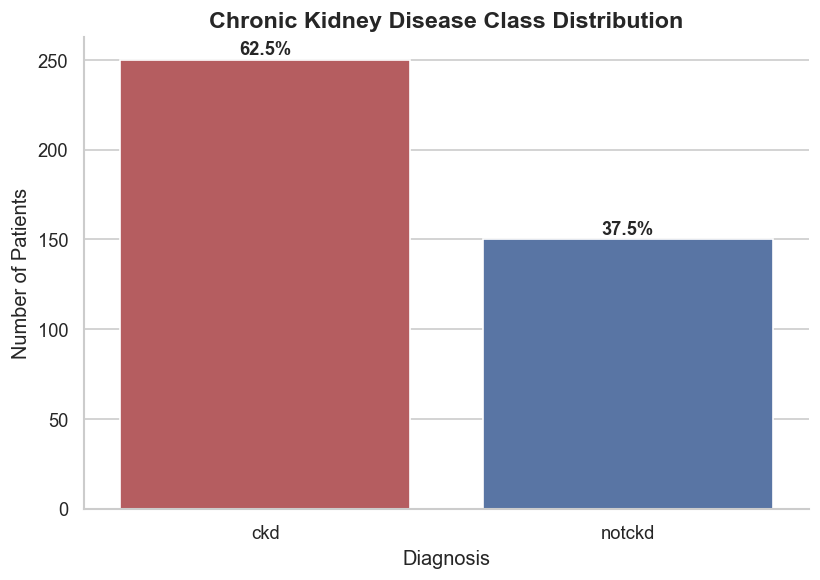

In [31]:
# Class Distribution

# Set style
sns.set_theme(style="whitegrid")

# Custom medical-style palette
palette = {
    "ckd": "#C44E52",      # muted clinical red
    "notckd": "#4C72B0"    # calm medical blue
}

# Compute percentages
vc = df["classification"].value_counts(normalize=True).mul(100).round(1)
counts = df["classification"].value_counts().reindex(vc.index)

# Create figure
plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df,
    x="classification",
    order=vc.index,
    palette=palette
)

# Titles & labels
ax.set_title("Chronic Kidney Disease Class Distribution", fontsize=14, weight="bold")
ax.set_ylabel("Number of Patients", fontsize=12)
ax.set_xlabel("Diagnosis", fontsize=12)

# Annotate percentages
for i, (c, p) in enumerate(zip(counts, vc)):
    ax.text(i, c + 3, f"{p}%", ha="center", fontsize=11, weight="bold")

# Clean aesthetics
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig("CKD_class_distribution.svg", dpi=300, bbox_inches="tight")
plt.savefig("CKD_class_distribution.pdf", bbox_inches="tight")

plt.show()

In [33]:
# Raw unique values (with repr)
for val in df["classification"].unique():
    print(repr(val))

df["classification"].value_counts(dropna=False)

'ckd'
'notckd'


classification
ckd       250
notckd    150
Name: count, dtype: int64

In [34]:
# Print stats for dirty versions
mask_dirty = df["classification"].isin(["ckd\t", "notckd\t", "notckd ", "ckd "])

print("Number of dirty labels:", mask_dirty.sum())
print(df.loc[mask_dirty, "classification"].value_counts())

Number of dirty labels: 0
Series([], Name: count, dtype: int64)


In [35]:
# Create cleaned column without modifying original yet
df["classification_clean"] = df["classification"].astype(str).str.strip()

print("Before cleaning:")
print(df["classification"].value_counts())

print("\nAfter cleaning:")
print(df["classification_clean"].value_counts())

Before cleaning:
classification
ckd       250
notckd    150
Name: count, dtype: int64

After cleaning:
classification_clean
ckd       250
notckd    150
Name: count, dtype: int64


In [36]:
# Clean the label column permanently

df["classification"] = df["classification"].astype(str).str.strip()

In [37]:
# Convert numeric-like object columns properly - Columns like pcv, wc, rc are numeric but stored as object.

numeric_like = ["pcv", "wc", "rc"]

for col in numeric_like:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [38]:
# Print numeric statistics grouped by class

df.groupby("classification").describe()

id                                                         \
                count   mean        std    min     25%    50%     75%    max   
classification                                                                 
ckd             250.0  124.5  72.312977    0.0   62.25  124.5  186.75  249.0   
notckd          150.0  324.5  43.445368  250.0  287.25  324.5  361.75  399.0   

                  age             ...       wc              rc            \
                count       mean  ...      75%      max  count      mean   
classification                    ...                                      
ckd             242.0  54.541322  ...  10600.0  26400.0  126.0  3.945238   
notckd          149.0  46.516779  ...   9250.0  11000.0  143.0  5.379021   

                                                   
                     std  min  25%  50%  75%  max  
classification                                     
ckd             0.865296  2.1  3.4  3.9  4.4  8.0  
notckd          0.596097  4.4  4.9  5.3  5.9  6.5  

[2 rows x 120 columns]

In [39]:
# Narrow down to key kidney markers

key_features = ["age", "bgr", "bu", "sc", "hemo", "pcv", "wc", "rc"]

df.groupby("classification")[key_features].describe()

age                                                      \
                count       mean        std   min   25%   50%   75%   max   
classification                                                              
ckd             242.0  54.541322  17.388899   2.0  47.0  59.0  66.0  90.0   
notckd          149.0  46.516779  15.631138  12.0  34.0  46.0  58.0  80.0   

                  bgr              ...       wc              rc            \
                count        mean  ...      75%      max  count      mean   
classification                     ...                                      
ckd             212.0  175.419811  ...  10600.0  26400.0  126.0  3.945238   
notckd          144.0  107.722222  ...   9250.0  11000.0  143.0  5.379021   

                                                   
                     std  min  25%  50%  75%  max  
classification                                     
ckd             0.865296  2.1  3.4  3.9  4.4  8.0  
notckd          0.596097  4.4  4.9  5.3  5.9  6.5  

[2 rows x 64 columns]

### Visualization: CKD vs NotCKD

Let’s plot the most medically important markers.

/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/526232655.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


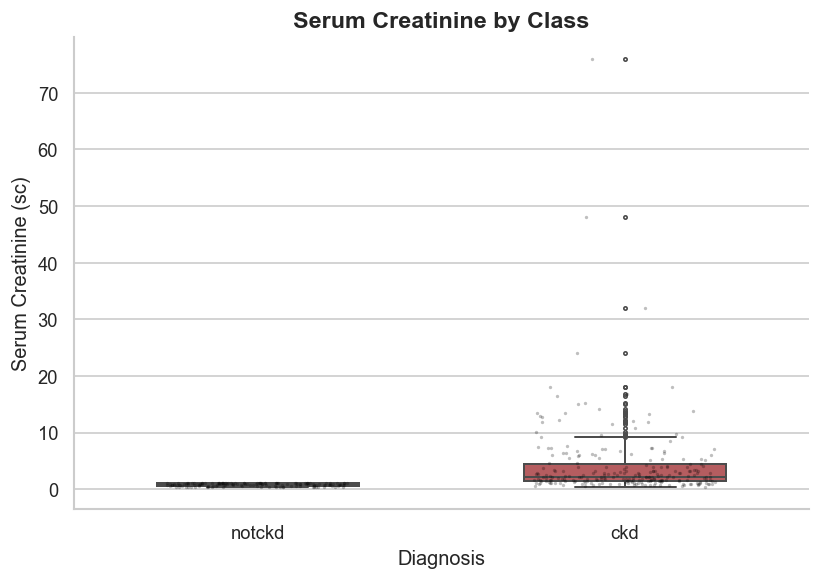

In [40]:
# Serum Creatinine (sc) - CKD patients → Higher creatinine

# Clean theme
sns.set_theme(style="whitegrid")

# Ensure consistent label formatting
df["classification"] = df["classification"].astype(str).str.strip()

# Medical-style palette (muted red vs calm blue)
palette = {
    "ckd": "#C44E52",
    "notckd": "#4C72B0",
}

plt.figure(figsize=(7,5))
ax = sns.boxplot(
    data=df,
    x="classification",
    y="sc",
    order=["notckd", "ckd"],   # compare baseline -> disease
    palette=palette,
    width=0.55,
    fliersize=2,
    linewidth=1.2
)

# Add jittered points for distribution detail (comment out if you want pure boxplot)
sns.stripplot(
    data=df,
    x="classification",
    y="sc",
    order=["notckd", "ckd"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25
)

ax.set_title("Serum Creatinine by Class", fontsize=14, weight="bold")
ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Serum Creatinine (sc)", fontsize=12)

sns.despine()
plt.tight_layout()

# Save SVG only
plt.savefig("CKD_serum_creatinine_by_class.svg", format="svg", bbox_inches="tight")

plt.show()

/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/1286328551.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


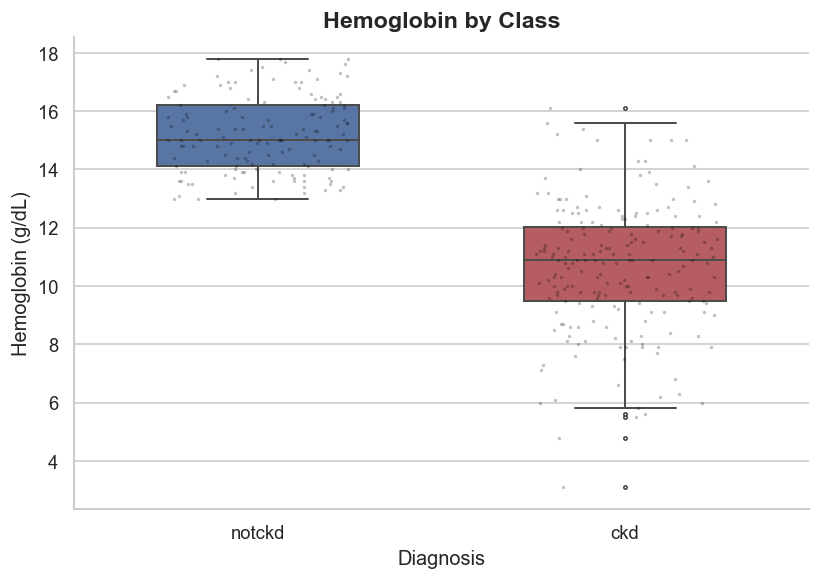

In [41]:
# Hemoglobin (hemo) - CKD patients → Lower hemoglobin

# Clean theme
sns.set_theme(style="whitegrid")

# Ensure labels are clean
df["classification"] = df["classification"].astype(str).str.strip()

# Same medical palette for consistency
palette = {
    "ckd": "#C44E52",      # muted clinical red
    "notckd": "#4C72B0"    # calm medical blue
}

plt.figure(figsize=(7,5))
ax = sns.boxplot(
    data=df,
    x="classification",
    y="hemo",
    order=["notckd", "ckd"],   # baseline first
    palette=palette,
    width=0.55,
    fliersize=2,
    linewidth=1.2
)

# Add light jittered points
sns.stripplot(
    data=df,
    x="classification",
    y="hemo",
    order=["notckd", "ckd"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25
)

ax.set_title("Hemoglobin by Class", fontsize=14, weight="bold")
ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Hemoglobin (g/dL)", fontsize=12)

sns.despine()
plt.tight_layout()

# Save as SVG only
plt.savefig("CKD_hemoglobin_by_class.svg", format="svg", bbox_inches="tight")

plt.show()

/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/3751420682.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


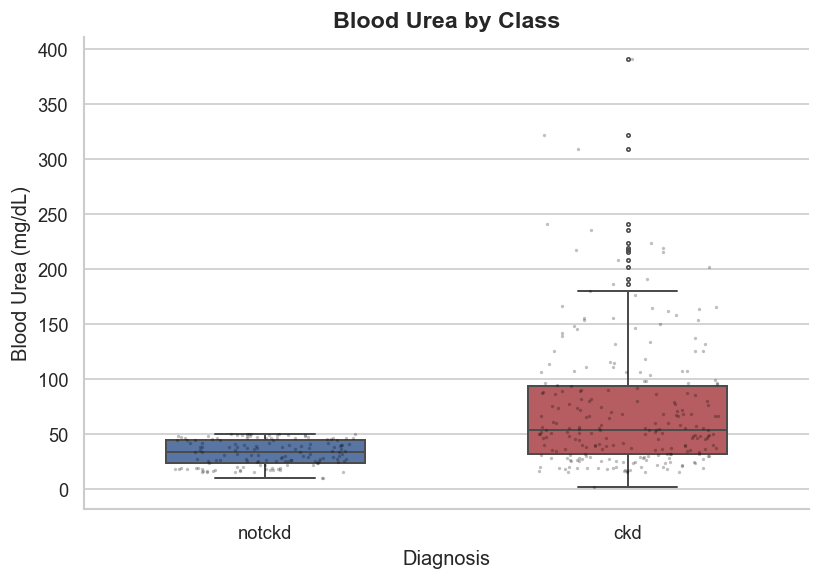

In [42]:
# Blood Urea (bu) - CKD patients → Higher blood urea

# Clean theme
sns.set_theme(style="whitegrid")

# Ensure labels are clean
df["classification"] = df["classification"].astype(str).str.strip()

# Consistent medical palette
palette = {
    "ckd": "#C44E52",      # muted clinical red
    "notckd": "#4C72B0"    # calm medical blue
}

plt.figure(figsize=(7,5))
ax = sns.boxplot(
    data=df,
    x="classification",
    y="bu",
    order=["notckd", "ckd"],
    palette=palette,
    width=0.55,
    fliersize=2,
    linewidth=1.2
)

# Add jittered data points
sns.stripplot(
    data=df,
    x="classification",
    y="bu",
    order=["notckd", "ckd"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25
)

ax.set_title("Blood Urea by Class", fontsize=14, weight="bold")
ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Blood Urea (mg/dL)", fontsize=12)

sns.despine()
plt.tight_layout()

# Save SVG only
plt.savefig("CKD_blood_urea_by_class.svg", format="svg", bbox_inches="tight")

plt.show()

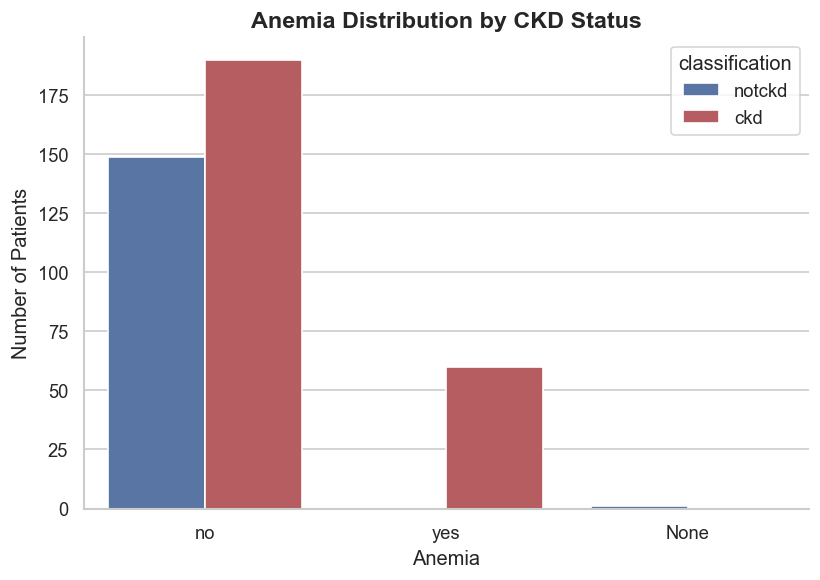

In [43]:
# Anemia vs CKD
# Much higher proportion of anemia = yes in CKD
# Low anemia prevalence in notCKD

sns.set_theme(style="whitegrid")

# Clean strings
df["classification"] = df["classification"].astype(str).str.strip()
df["ane"] = df["ane"].astype(str).str.strip()

# Drop missing anemia rows for clean visualization
df_ane = df.dropna(subset=["ane"])

# Medical palette
palette = {
    "ckd": "#C44E52",
    "notckd": "#4C72B0"
}

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df_ane,
    x="ane",
    hue="classification",
    hue_order=["notckd", "ckd"],
    palette=palette
)

ax.set_title("Anemia Distribution by CKD Status", fontsize=14, weight="bold")
ax.set_xlabel("Anemia")
ax.set_ylabel("Number of Patients")

sns.despine()
plt.tight_layout()

plt.savefig("CKD_anemia_distribution.svg", format="svg", bbox_inches="tight")

plt.show()

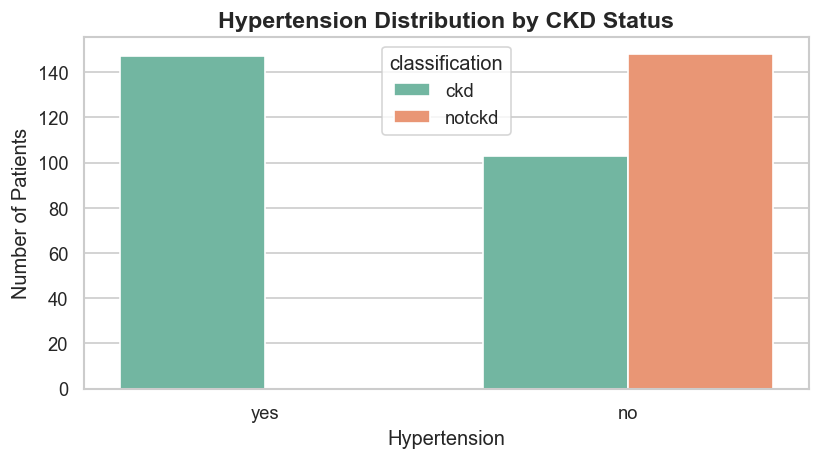

In [70]:
# Hypertension Distribution by CKD Status

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="htn",
    hue="classification",
    palette="Set2"
)

ax.set_title("Hypertension Distribution by CKD Status", fontsize=14, weight="bold")
ax.set_xlabel("Hypertension")
ax.set_ylabel("Number of Patients")

plt.tight_layout()

# Save figure
plt.savefig("Hypertension_CKD.svg", format="svg", bbox_inches="tight")

plt.show()

/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/1668190732.py:18: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j3/hr2vkz5d6rsdcwsjr4bf6ydh0000gn/T/ipykernel_64328/1668190732.py:21: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig("Diabetes_CKD.svg", format="svg", bbox_inches="tight")
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


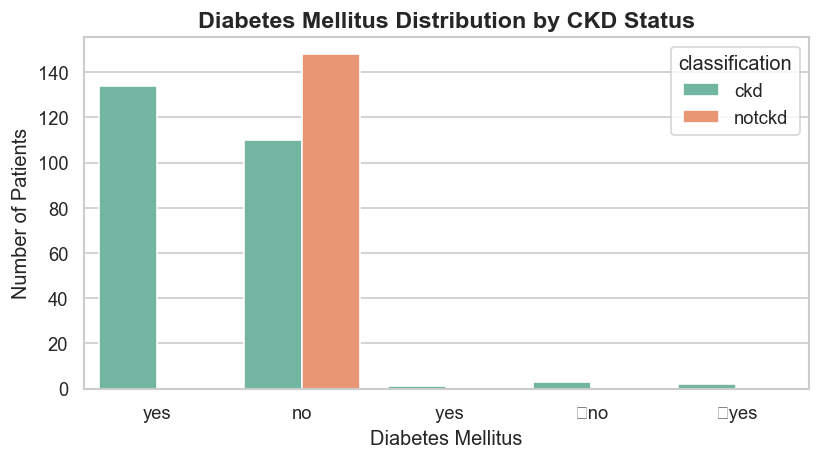

In [71]:
# Diabetes Mellitus Distribution by CKD Status

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="dm",
    hue="classification",
    palette="Set2"
)

ax.set_title("Diabetes Mellitus Distribution by CKD Status", fontsize=14, weight="bold")
ax.set_xlabel("Diabetes Mellitus")
ax.set_ylabel("Number of Patients")

plt.tight_layout()

# Save figure
plt.savefig("Diabetes_CKD.svg", format="svg", bbox_inches="tight")

plt.show()

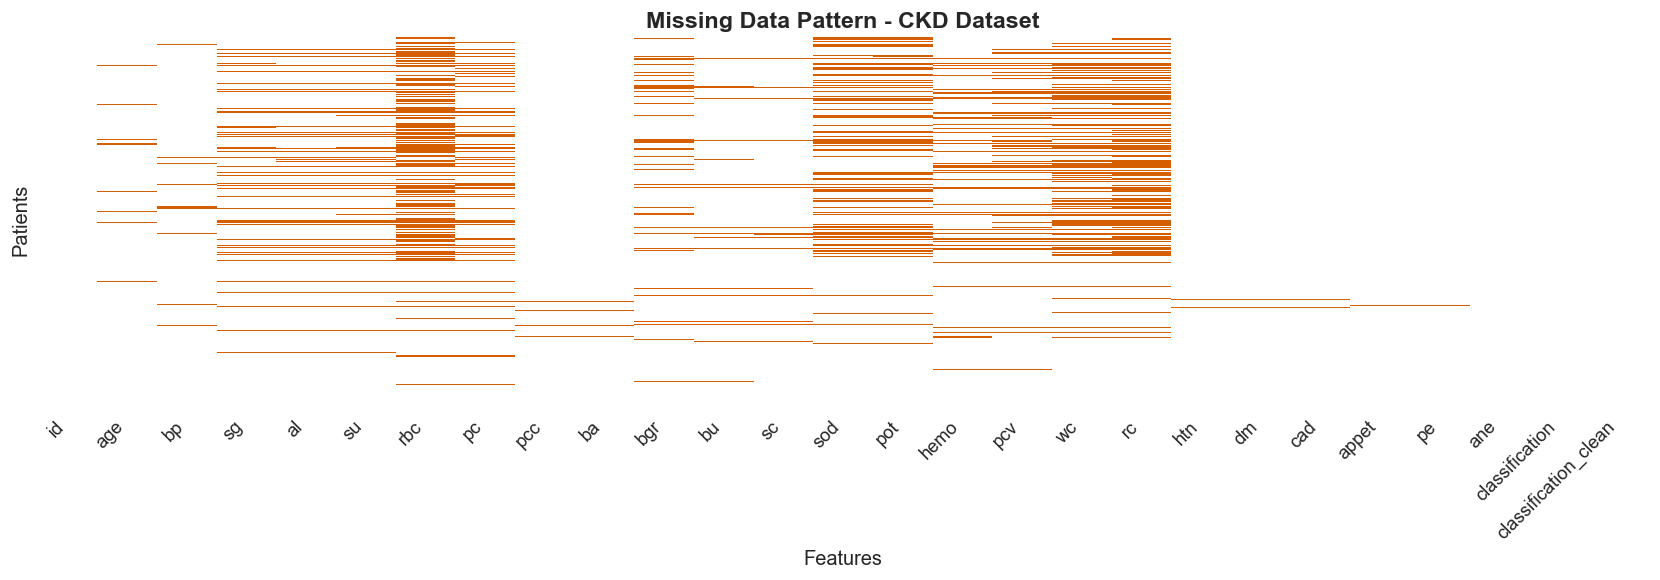

In [47]:
# Missingness Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Clean theme
sns.set_theme(style="white")

plt.figure(figsize=(14,5))

# Create heatmap
ax = sns.heatmap(
    df.isna(),
    cmap=["#FFFFFF", "#D55E00"],   # white = present, darker red = missing
    cbar=False,
    yticklabels=False              # too many patients to display
)

# Title
ax.set_title("Missing Data Pattern - CKD Dataset", fontsize=14, weight="bold")

# Axis labels
ax.set_xlabel("Features")
ax.set_ylabel("Patients")

# Rotate feature names for readability
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save as SVG (vector graphics for report)
plt.savefig("CKD_missingness_heatmap.svg", format="svg", bbox_inches="tight")

plt.show()

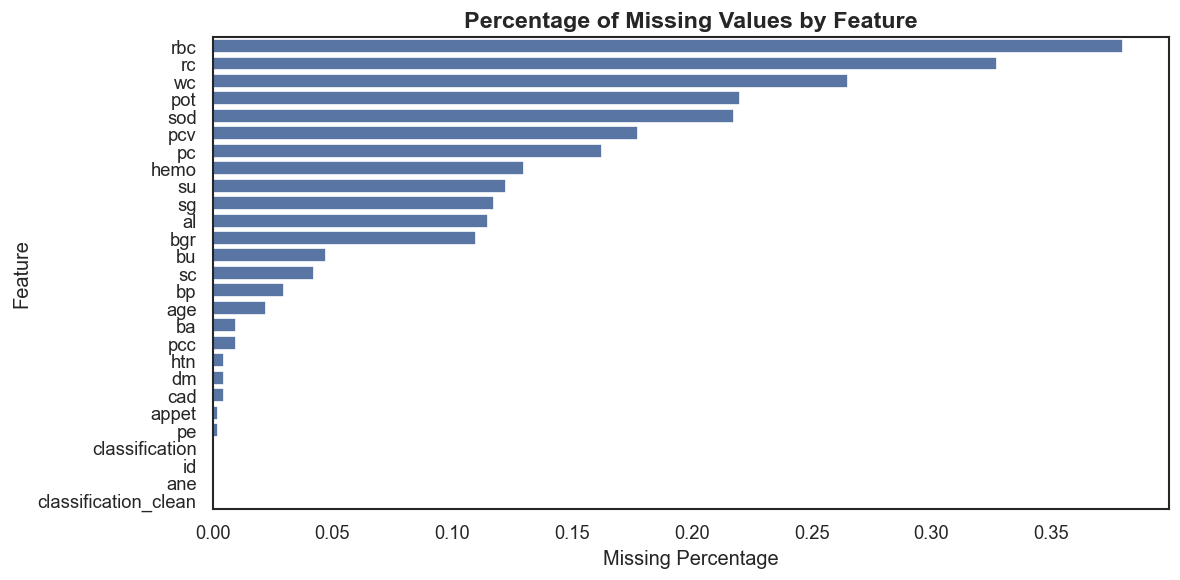

In [46]:
# Missingness percentage bar plot

missing_pct = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#4C72B0")

plt.title("Percentage of Missing Values by Feature", fontsize=14, weight="bold")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("CKD_missing_percentage.svg", format="svg", bbox_inches="tight")
plt.show()

In [48]:
# Confirm totals + per-column summary

total_missing = int(df.isna().sum().sum())
rows_with_missing = int(df.isna().any(axis=1).sum())

print("Total missing cells:", total_missing)
print("Rows with any missing:", rows_with_missing, "out of", len(df))

missing_table = (
    df.isna().sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(1))
      .sort_values("missing_count", ascending=False)
)

missing_table.head(15)

Total missing cells: 1011
Rows with any missing: 242 out of 400


,missing_count,missing_pct
rbc,152,38.0
rc,131,32.8
wc,106,26.5
pot,88,22.0
sod,87,21.8
pcv,71,17.8
pc,65,16.2
hemo,52,13.0
su,49,12.2
sg,47,11.8


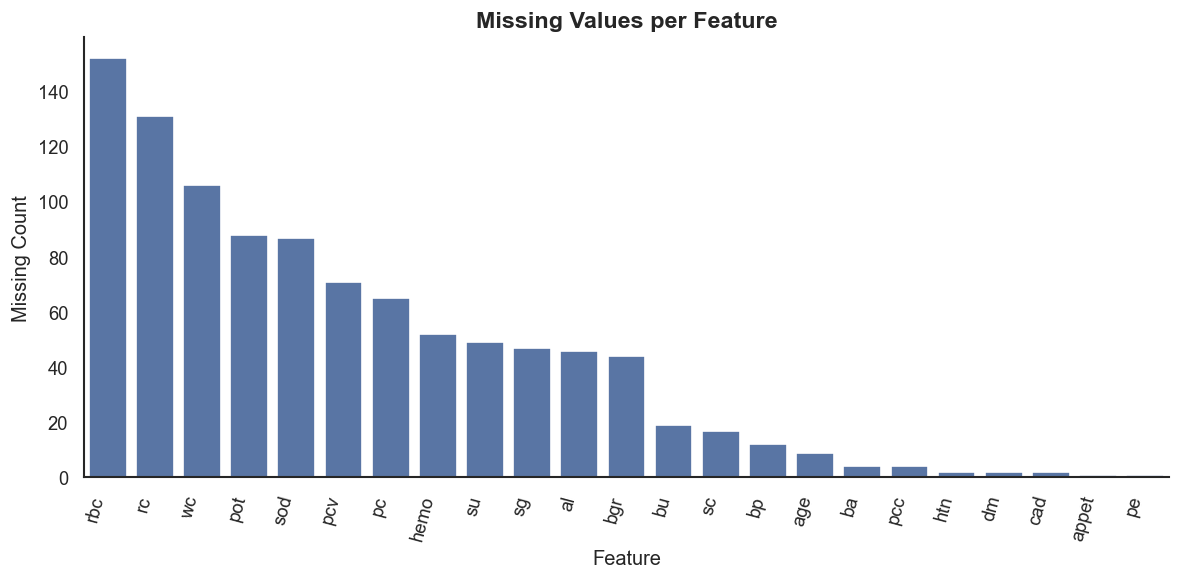

In [49]:
# Plot of missing values per feature

plt.figure(figsize=(10,5))
ms = missing_table[missing_table["missing_count"] > 0]
ax = sns.barplot(x=ms.index, y=ms["missing_count"])
ax.set_title("Missing Values per Feature", fontsize=14, weight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Count")
plt.xticks(rotation=75, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("CKD_missing_values_bar.svg", format="svg", bbox_inches="tight")
plt.show()

## 3) Statistical Feature Checks

**Goal of this section**
- Provide simple statistical evidence that features differ by class:
  - Numeric: Welch’s t-test (robust to unequal variance)
  - Categorical: Chi-square test + effect size (Cramér’s V)
    

### Statistical tests (per feature)

We’ll do:

t-test (Welch) for numeric features (handles unequal variance)

chi-square for categorical features

(We’ll ignore missing values per feature.)

In [50]:
# Prep: split into groups

df_ckd = df[df["classification"] == "ckd"]
df_not = df[df["classification"] == "notckd"]

numeric_cols = df.select_dtypes(include=["number"]).columns.drop(["id"], errors="ignore")
categorical_cols = df.select_dtypes(include=["object"]).columns.drop(["classification"], errors="ignore")

print("Numeric cols:", list(numeric_cols))
print("Categorical cols:", list(categorical_cols))

Numeric cols: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical cols: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification_clean']


In [51]:
# Welch t-tests for numeric features

t_results = []
for col in numeric_cols:
    x = df_ckd[col].dropna()
    y = df_not[col].dropna()
    if len(x) >= 5 and len(y) >= 5:
        tstat, pval = stats.ttest_ind(x, y, equal_var=False, nan_policy="omit")
        # effect size (Cohen's d, using pooled std approx)
        nx, ny = len(x), len(y)
        sx, sy = x.std(ddof=1), y.std(ddof=1)
        s_pooled = np.sqrt(((nx-1)*sx*sx + (ny-1)*sy*sy) / (nx+ny-2)) if (nx+ny-2) > 0 else np.nan
        d = (x.mean() - y.mean()) / s_pooled if s_pooled and s_pooled > 0 else np.nan

        t_results.append({
            "feature": col,
            "ckd_mean": x.mean(),
            "notckd_mean": y.mean(),
            "t_stat": tstat,
            "p_value": pval,
            "cohens_d": d,
            "n_ckd": nx,
            "n_notckd": ny
        })

t_df = pd.DataFrame(t_results).sort_values("p_value")
t_df.head(15)

,feature,ckd_mean,notckd_mean,t_stat,p_value,cohens_d,n_ckd,n_notckd
10,hemo,10.647549,15.188194,-24.356516,3.607618e-76,-2.434872,204,144
2,sg,1.013918,1.022414,-22.212677,1.038925e-67,-2.178733,208,145
11,pcv,32.939891,46.335616,-21.152450,2.307434e-61,-2.217147,183,146
3,al,1.722488,0.000000,18.141409,9.986200e-45,1.632441,209,145
13,rc,3.945238,5.379021,-15.618593,2.126879e-37,-1.952017,126,143
5,bgr,175.419811,107.722222,10.397884,4.348030e-21,0.939414,212,144
6,bu,72.389030,32.798611,10.090710,1.799023e-20,0.846607,237,144
4,su,0.766990,0.000000,8.163068,3.277656e-14,0.742088,206,145
7,sc,4.414916,0.868966,7.862118,1.307916e-13,0.646608,238,145
8,sod,133.901786,141.731034,-7.548610,1.119312e-12,-0.810328,168,145


In [72]:
# Chi-square tests for categorical features

t_results = []

for col in numeric_cols:
    x = df_ckd[col]
    y = df_not[col]

    if x.notna().sum() > 1 and y.notna().sum() > 1:
        tstat, pval = stats.ttest_ind(x, y, equal_var=False, nan_policy="omit")
        t_results.append({
            "feature": col,
            "p_value": pval,
            "ckd_mean": x.mean(),
            "notckd_mean": y.mean()
        })

t_df = pd.DataFrame(t_results).sort_values("p_value")
t_df.head(15)

,feature,p_value,ckd_mean,notckd_mean
0,id,7.122653e-122,124.500000,324.500000
11,hemo,3.607618e-76,10.647549,15.188194
3,sg,1.038925e-67,1.013918,1.022414
12,pcv,2.307434e-61,32.939891,46.335616
4,al,9.986200e-45,1.722488,0.000000
14,rc,2.126879e-37,3.945238,5.379021
6,bgr,4.348030e-21,175.419811,107.722222
7,bu,1.799023e-20,72.389030,32.798611
5,su,3.277656e-14,0.766990,0.000000
8,sc,1.307916e-13,4.414916,0.868966


In [54]:
# Check Correlation With Target

for col in df.columns:
    if col != "classification":
        print(col, df.groupby("classification")[col].nunique())

id classification
ckd       250
notckd    150
Name: id, dtype: int64
age classification
ckd       69
notckd    58
Name: age, dtype: int64
bp classification
ckd       10
notckd     3
Name: bp, dtype: int64
sg classification
ckd       5
notckd    2
Name: sg, dtype: int64
al classification
ckd       6
notckd    1
Name: al, dtype: int64
su classification
ckd       6
notckd    1
Name: su, dtype: int64
rbc classification
ckd       2
notckd    1
Name: rbc, dtype: int64
pc classification
ckd       2
notckd    1
Name: pc, dtype: int64
pcc classification
ckd       2
notckd    1
Name: pcc, dtype: int64
ba classification
ckd       2
notckd    1
Name: ba, dtype: int64
bgr classification
ckd       135
notckd     59
Name: bgr, dtype: int64
bu classification
ckd       117
notckd     35
Name: bu, dtype: int64
sc classification
ckd       83
notckd     9
Name: sc, dtype: int64
sod classification
ckd       32
notckd    14
Name: sod, dtype: int64
pot classification
ckd       40
notckd    17
Name: pot, dtyp

In [55]:
# Inspect cross-tabs

pd.crosstab(df["ane"], df["classification"])
pd.crosstab(df["htn"], df["classification"])
pd.crosstab(df["dm"], df["classification"])

classification,ckd,notckd
dm,,
\tno,3,0
\tyes,2,0
yes,1,0
no,110,148
yes,134,0


## 4) Final Clean Dataset for Modeling

**Goal of this section**
- Produce a clean dataset with:
  - consistent labels
  - standardized missing values
  - clearly identified numeric vs categorical features


### Final Clean Dataset

In [34]:
# Drop Post-Diagnosis Clinical Flags and id

# Fix leading/trailing whitespace everywhere
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Drop leakage features
X = df.drop(columns=["classification", "id", "htn", "dm", "cad", "ane", "pe", "appet"])
y = (df["classification"] == "ckd").astype(int)

In [35]:
# Identify Feature Types

num_features = X.select_dtypes(include=["number"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

print("Numeric:", list(num_features))
print("Categorical:", list(cat_features))

Numeric: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical: ['rbc', 'pc', 'pcc', 'ba', 'classification_clean']


In [66]:
df.groupby("classification")[["sc", "bu", "hemo", "al"]].describe()

sc                                                    \
                count      mean       std  min    25%   50%   75%   max   
classification                                                            
ckd             238.0  4.414916  6.950275  0.5  1.425  2.25  4.55  76.0   
notckd          145.0  0.868966  0.255092  0.4  0.600  0.90  1.10   1.2   

                   bu             ...    hemo           al            \
                count       mean  ...     75%   max  count      mean   
classification                    ...                                  
ckd             237.0  72.389030  ...  12.025  16.1  209.0  1.722488   
notckd          144.0  32.798611  ...  16.200  17.8  145.0  0.000000   

                                                   
                     std  min  25%  50%  75%  max  
classification                                     
ckd             1.372645  0.0  0.0  2.0  3.0  5.0  
notckd          0.000000  0.0  0.0  0.0  0.0  0.0  

[2 rows x 32 columns]

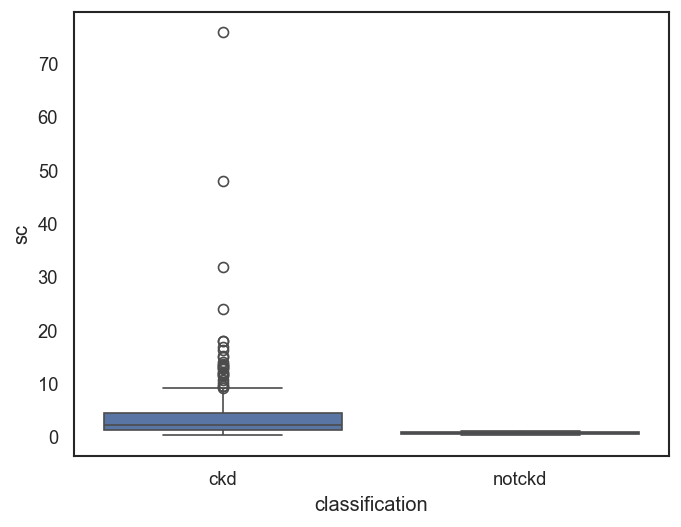

In [67]:
sns.boxplot(data=df, x="classification", y="sc")
plt.show()

## 5) Phase I → Phase II Bridge: Imputation & Preprocessing Pipelines

**Goal of this section**
- Create scikit-learn preprocessing pipelines that can be reused in Phase II (5-model training notebook):
  - Numeric: median imputation + scaling
  - Categorical: most-frequent imputation + one-hot encoding
- Save artifacts to disk to ensure reproducibility:
  - `preprocessor.joblib`
  - `feature_names.csv`
  - saved train/test indices


## Phase I Extension: Imputation & Preprocessing for Modeling

This section keeps the EDA/plots above intact and prepares a clean, reproducible feature matrix for Phase II modeling (with train/test split, imputers, encoding, and scaling).

In [56]:
import os
from pathlib import Path
import joblib

# Output folders (change CKD_OUTPUT_DIR if you want a different location)
OUTPUT_DIR = Path(os.environ.get("CKD_OUTPUT_DIR", "outputs")) / "phase1_preprocessing"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "artifacts"

for d in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Outputs will be written to:", OUTPUT_DIR.resolve())


Outputs will be written to: /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/outputs/phase1_preprocessing


In [57]:
# Target cleanup (consistent labels)
df["classification"] = df["classification"].astype(str).str.strip().str.lower()

# Encode target: ckd=1, notckd=0
y = df["classification"].map({"ckd": 1, "notckd": 0})

# Basic sanity checks
assert y.notna().all(), "Found unexpected class labels in `classification`."
print("y distribution:", y.value_counts().to_dict())


y distribution: {1: 250, 0: 150}


In [59]:
# Leakage control
# `dm` may extremely predictive and can lead to near-perfect accuracy.
# We DON'T drop anything automatically; instead we define a list you can toggle.
LEAKAGE_CANDIDATES = ["dm"]  # add others only if results suggests near-deterministic leakage

# Features
X = df.drop(columns=["classification"])

print("Feature columns:", len(X.columns))
print("Leakage candidates present:", [c for c in LEAKAGE_CANDIDATES if c in X.columns])


Feature columns: 26
Leakage candidates present: ['dm']


In [60]:
from sklearn.model_selection import train_test_split

def make_splits(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = make_splits(X, y)
print(X_train.shape, X_test.shape)


(320, 26) (80, 26)


In [61]:
# Column typing
# Treat numeric columns as those convertible to float; everything else categorical.
# (This matches how CKD dataset comes with mixed object columns.)
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))
print("Example categorical levels (first 5 cols):")
for c in categorical_cols[:5]:
    print(c, "->", sorted(pd.Series(X_train[c].dropna().unique()).astype(str).str.strip().unique())[:10])


Numeric cols: 15
Categorical cols: 11
Example categorical levels (first 5 cols):
rbc -> ['abnormal', 'normal']
pc -> ['abnormal', 'normal']
pcc -> ['notpresent', 'present']
ba -> ['notpresent', 'present']
htn -> ['no', 'yes']


In [62]:
# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [63]:
def build_preprocessor(drop_cols=None):
    drop_cols = drop_cols or []
    drop_cols = [c for c in drop_cols if c in X.columns]

    X_dropped = X.drop(columns=drop_cols) if drop_cols else X.copy()
    X_train_d, X_test_d, y_train_d, y_test_d = make_splits(X_dropped, y)

    num_cols = X_train_d.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X_train_d.columns if c not in num_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return pre, (X_train_d, X_test_d, y_train_d, y_test_d), (num_cols, cat_cols), drop_cols

# Default: keep all columns (no leakage drop)
preprocessor, splits, col_info, dropped = build_preprocessor(drop_cols=[])
X_train_d, X_test_d, y_train_d, y_test_d = splits

X_train_p = preprocessor.fit_transform(X_train_d)
X_test_p = preprocessor.transform(X_test_d)

feature_names = preprocessor.get_feature_names_out()

print("Dropped cols:", dropped)
print("Transformed shapes:", X_train_p.shape, X_test_p.shape)
print("Feature names:", len(feature_names))


Dropped cols: []
Transformed shapes: (320, 51) (80, 51)
Feature names: 51


In [64]:
# Save artifacts for Phase II
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
pd.Series(feature_names).to_csv(TABLE_DIR / "feature_names.csv", index=False, header=["feature"])

# Save indices to reproduce split exactly (for reproducibility)
pd.Series(X_train_d.index, name="train_index").to_csv(TABLE_DIR / "train_index.csv", index=False)
pd.Series(X_test_d.index, name="test_index").to_csv(TABLE_DIR / "test_index.csv", index=False)

print("Saved:")
print("-", (MODEL_DIR / "preprocessor.joblib").resolve())
print("-", (TABLE_DIR / "feature_names.csv").resolve())
print("-", (TABLE_DIR / "train_index.csv").resolve())
print("-", (TABLE_DIR / "test_index.csv").resolve())


Saved:
- /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/outputs/phase1_preprocessing/artifacts/preprocessor.joblib
- /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/outputs/phase1_preprocessing/tables/feature_names.csv
- /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/outputs/phase1_preprocessing/tables/train_index.csv
- /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/outputs/phase1_preprocessing/tables/test_index.csv


In [65]:
# Optional: build a leakage-controlled version (recommended if we see unrealistically high accuracy later)
# This DOES NOT train any models here; it just prepares a second preprocessor/split for Phase II.
preprocessor_noleak, splits_noleak, col_info_noleak, dropped_noleak = build_preprocessor(drop_cols=LEAKAGE_CANDIDATES)

X_train_nl, X_test_nl, y_train_nl, y_test_nl = splits_noleak
X_train_p_nl = preprocessor_noleak.fit_transform(X_train_nl)
X_test_p_nl = preprocessor_noleak.transform(X_test_nl)
feature_names_nl = preprocessor_noleak.get_feature_names_out()

joblib.dump(preprocessor_noleak, MODEL_DIR / "preprocessor_no_leak.joblib")
pd.Series(feature_names_nl).to_csv(TABLE_DIR / "feature_names_no_leak.csv", index=False, header=["feature"])

print("No-leak dropped cols:", dropped_noleak)
print("No-leak transformed shapes:", X_train_p_nl.shape, X_test_p_nl.shape)


No-leak dropped cols: ['dm']
No-leak transformed shapes: (320, 45) (80, 45)


In [73]:
# Clean EDA report (auto-generated HTML) - A clean one-command EDA report:

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="CKD EDA Report", explorative=True)
profile.to_file("CKD_EDA_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 27/27 [00:00<00:00, 547.15it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig(


Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]